# Master fitting file

Change only: 

`MODE`: `fit` or `load`

`CONFIG_FILE`: `fit_{experiments}_{model}.json`

In [19]:
# ============================================================
# Packages
# ============================================================

import json
import xlrd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from model_registry import get_model
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

In [20]:
# ============================================================
# Create output folders
# ============================================================

RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

In [21]:
# ============================================================
# Execution mode
# ============================================================

MODE = "fit"    # run optimization
# MODE = "load" # reuse previous fit

In [22]:
# ============================================================
# Load config
# ============================================================

# Path to the config file defining this run
CONFIG_FILE = "configs/fit_exps12345_model3.json"

# Load JSON config into a Python dictionary
config = json.load(open(CONFIG_FILE))

# Name used to label outputs and saved results
RUN_NAME = config["run_name"]

# Name of the model to use (mapped via model_registry)
MODEL_NAME = config["model_name"]

# Load the selected model module
model = get_model(MODEL_NAME)

# Experimental conditions used for fitting
FIT_CONDITIONS = config["fit_conditions"]

# Full list of all possible experimental conditions
ALL_CONDITIONS = config["all_conditions"]




# # Identify the single condition not used in fitting (held-out)
# HELD_OUT_CONDITION = [c for c in ALL_CONDITIONS if c not in FIT_CONDITIONS][0]
# Identify held-out condition if one exists
held_out_list = [
    c for c in ALL_CONDITIONS
    if c not in FIT_CONDITIONS
]

# Use None when fitting all conditions
HELD_OUT_CONDITION = (
    held_out_list[0]
    if len(held_out_list) > 0
    else None
)



# List of parameters to be optimized
FIT_PARAMS = config["fit_params"]

# Dictionary of all parameters with their central (default) values
ALL_PARAM_INFO = {
    p: {"central": float(v)}
    for p, v in config["all_param_central"].items()
}

# Bounds for fitted parameters in normal (not log) scale
CUSTOM_PARAM_BOUNDS = {
    p: tuple(map(float, bounds))
    for p, bounds in config["custom_param_bounds"].items()
}

# Number of random initial guesses for multi-start fitting
N_STARTS = int(config["n_starts"])

# Random seed for reproducibility
RANDOM_SEED = int(config["random_seed"])

# Path to the Excel file containing experimental data
EXCEL_FILE = config.get("excel_file", "data/in_vitro_ctRSD_modeling_data.xls")

# Name of the sheet in the Excel file to read
EXCEL_SHEET = config.get("excel_sheet", "Fig. 4H (SciAdv) fuel")

# Mapping from condition index to row cutoff for fit/plateau split
row_end_map = {int(k): int(v) for k, v in config["row_end_map"].items()}

# Directory where results will be saved
RESULTS_DIR = Path(config.get("results_dir", "results"))

# Create results directory if it does not exist
RESULTS_DIR.mkdir(exist_ok=True)

# File path for saving/loading fitted parameters
FIT_RESULTS_FILE = RESULTS_DIR / f"{RUN_NAME}_results.npz"

# ============================================================
# Run summary
# ============================================================
print("RUN SUMMARY")
print("="*52)

summary = {
    "Run name": RUN_NAME,
    "Model": MODEL_NAME,
    "Mode": MODE,
    "Fit conditions": FIT_CONDITIONS,
    "Held-out": HELD_OUT_CONDITION,
    "Fit parameters": FIT_PARAMS,
    "N starts": N_STARTS,
    "Random seed": RANDOM_SEED,
    "Excel file": EXCEL_FILE,
    "Sheet": EXCEL_SHEET,
    "Results file": FIT_RESULTS_FILE
}

for k, v in summary.items():
    print(f"{k:<16}: {v}")

RUN SUMMARY
Run name        : fit_exps12345_model3
Model           : model3_misfoldgate_fuel
Mode            : fit
Fit conditions  : ['1p25in_0fuel', '2p5in_0fuel', '0in_25fuel', '1p25in_25fuel', '2p5in_25fuel']
Held-out        : None
Fit parameters  : ['k_txn', 'ksd', 'kfsd', 'krev', 'kf_rep', 'kRz', 'basal_frac', 'misfold_frac', 'kmG_F']
N starts        : 50
Random seed     : 1
Excel file      : data/in_vitro_ctRSD_modeling_data.xls
Sheet           : Fig. 4H (SciAdv) fuel
Results file    : results/fit_exps12345_model3_results.npz


In [23]:
# ============================================================
# Load experimental data
# ============================================================

# Open the Excel file specified in the config
wb = xlrd.open_workbook(EXCEL_FILE)

# Select the worksheet containing the experimental data
ws = wb.sheet_by_name(EXCEL_SHEET)

# Map condition keys: (column index, input template concentration, fuel template concentration)
CONDITIONS = {
    "0in_0fuel": (0, 0, 0),
    "1p25in_0fuel": (1, 1.25, 0),
    "2p5in_0fuel": (2, 2.5, 0),
    "0in_25fuel": (3, 0, 25),
    "1p25in_25fuel": (4, 1.25, 25),
    "2p5in_25fuel": (5, 2.5, 25),
}

# ============================================================
# Data summary
# ============================================================

print("\n" + "="*52)
print("DATA SUMMARY")
print("="*52)

# Print file and sheet being used
print(f"Excel file     : {EXCEL_FILE}")
print(f"Sheet          : {EXCEL_SHEET}")

# Print total number of rows (time points available)
print(f"Total rows     : {ws.nrows}")

# Print condition mapping in readable form
print("\nConditions:")
for k, (col_idx, IN, F) in CONDITIONS.items():
    print(f"{k:<10} → col {col_idx}, IN = {IN} nM, Fuel = {F} nM")

print("="*52 + "\n")


DATA SUMMARY
Excel file     : data/in_vitro_ctRSD_modeling_data.xls
Sheet          : Fig. 4H (SciAdv) fuel
Total rows     : 2510

Conditions:
0in_0fuel  → col 0, IN = 0 nM, Fuel = 0 nM
1p25in_0fuel → col 1, IN = 1.25 nM, Fuel = 0 nM
2p5in_0fuel → col 2, IN = 2.5 nM, Fuel = 0 nM
0in_25fuel → col 3, IN = 0 nM, Fuel = 25 nM
1p25in_25fuel → col 4, IN = 1.25 nM, Fuel = 25 nM
2p5in_25fuel → col 5, IN = 2.5 nM, Fuel = 25 nM



In [24]:
# ============================================================
# Build dataset
# ============================================================

def build_dataset(cond):

    # Look up column index and concentrations for this condition
    col_idx, IN_conc, Fuel_conc = CONDITIONS[cond]

    # Row index where fitting region ends and plateau begins
    row_end = row_end_map[col_idx]

    # Lists to store time and experimental data for fit region
    t = []
    x = []

    # Loop through rows corresponding to the fit region
    for r in range(3, row_end):

        # Time is always in column 0
        t.append(ws.cell_value(r, 0))

        # Experimental signal is in (col_idx + 1) due to Excel layout
        x.append(ws.cell_value(r, col_idx + 1))

    # Convert fit-region time to numpy array
    t = np.array(t)

    # Convert fit-region signal from fraction reacted → nM reacted
    x = np.array(x) * 500.0

    # Lists to store plateau-region time and data
    t_plateau = []
    x_plateau = []

    # Loop through rows corresponding to plateau region
    for r in range(row_end, ws.nrows):

        # Time is always in column 0
        t_plateau.append(ws.cell_value(r, 0))

        # Experimental signal is in (col_idx + 1)
        x_plateau.append(ws.cell_value(r, col_idx + 1))

    # Convert plateau-region time to numpy array
    t_plateau = np.array(t_plateau)

    # Convert plateau signal from fraction reacted → nM reacted
    x_plateau = np.array(x_plateau) * 500.0

    # Estimate plateau average
    plateau_avg = np.mean(x_plateau) if len(x_plateau) > 0 else x[-1]

    # Use plateau average as initial reporter pool
    DRL_0 = plateau_avg

    # Return dataset dictionary containing everything needed later
    return {
        "name": cond,
        "t_exp": t,
        "x_exp": x,
        "t_plateau": t_plateau,
        "x_plateau": x_plateau,
        "plateau_avg": plateau_avg,
        "IN_conc": IN_conc,
        "Fuel_conc": Fuel_conc,
        "DRL_0": DRL_0,
        "RSD_temp": 25.0
    }


# Build datasets used for fitting
datasets = [build_dataset(c) for c in FIT_CONDITIONS]

# # Build dataset used for held-out prediction
# HELD_OUT_DATASET = build_dataset(HELD_OUT_CONDITION)
# Build dataset used for held-out prediction, if one exists
if HELD_OUT_CONDITION is not None:
    HELD_OUT_DATASET = build_dataset(HELD_OUT_CONDITION)
else:
    HELD_OUT_DATASET = None

# ============================================================
# Dataset summary
# ============================================================

print("="*52)
print("DATASET SUMMARY")
print("="*52)

print("\nFitted datasets:")
for d in datasets:
    print(
        f"{d['name']:<18} | "
        f"fit points = {len(d['t_exp']):<4} | "
        f"plateau points = {len(d['x_plateau']):<4} | "
        f"IN = {d['IN_conc']} nM | "
        f"Fuel = {d['Fuel_conc']} nM | "
        f"DRL_0 = {d['DRL_0']:.2f}"
    )

if HELD_OUT_DATASET is not None:
    d = HELD_OUT_DATASET
    print("\nHeld-out dataset:")
    print(
        f"{d['name']:<18} | "
        f"fit points = {len(d['t_exp']):<4} | "
        f"plateau points = {len(d['x_plateau']):<4} | "
        f"IN = {d['IN_conc']} nM | "
        f"Fuel = {d['Fuel_conc']} nM | "
        f"DRL_0 = {d['DRL_0']:.2f}"
    )
else:
    print("\nHeld-out dataset: None")

DATASET SUMMARY

Fitted datasets:
1p25in_0fuel       | fit points = 1306 | plateau points = 1201 | IN = 1.25 nM | Fuel = 0 nM | DRL_0 = 490.73
2p5in_0fuel        | fit points = 523  | plateau points = 1984 | IN = 2.5 nM | Fuel = 0 nM | DRL_0 = 485.83
0in_25fuel         | fit points = 784  | plateau points = 1723 | IN = 0 nM | Fuel = 25 nM | DRL_0 = 491.79
1p25in_25fuel      | fit points = 262  | plateau points = 2245 | IN = 1.25 nM | Fuel = 25 nM | DRL_0 = 487.32
2p5in_25fuel       | fit points = 197  | plateau points = 2310 | IN = 2.5 nM | Fuel = 25 nM | DRL_0 = 482.73

Held-out dataset: None


Saved figure → figures/fit_exps12345_model3_experimentaldata.png


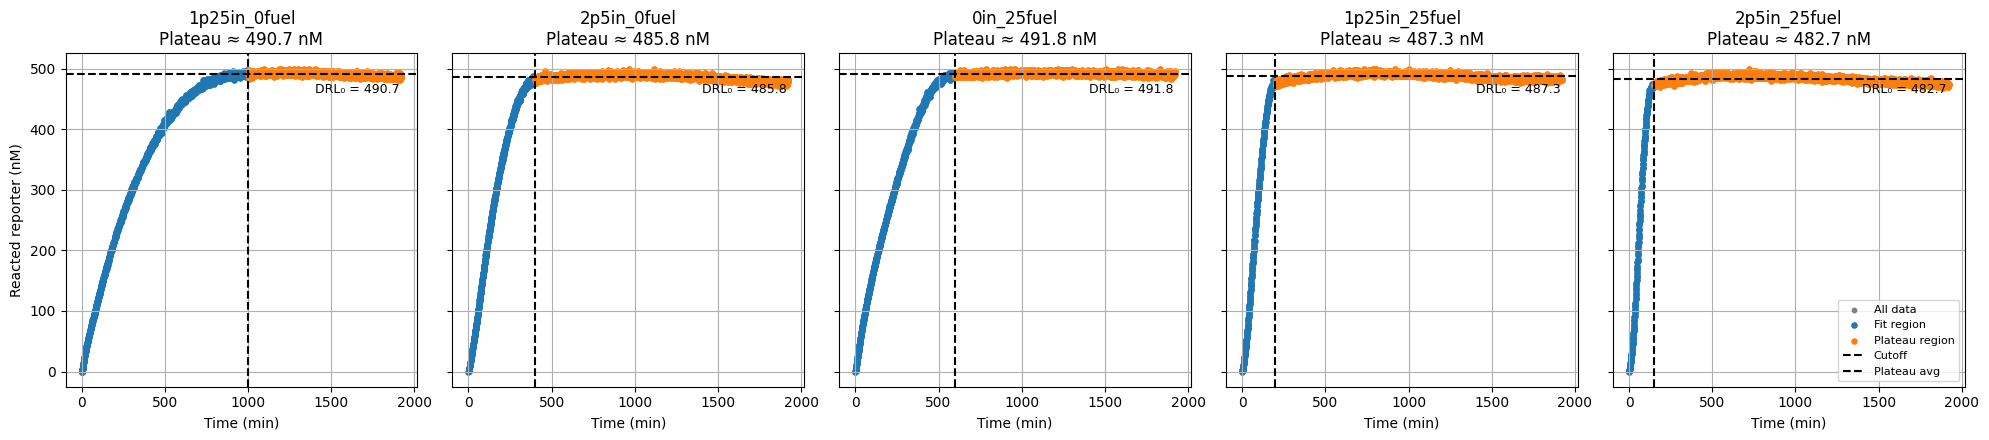

In [25]:
# ============================================================
# Visual check: fit region vs plateau region
# ============================================================

# Number of fitted datasets
n = len(datasets)

# Create one subplot per fitted dataset
fig, axes = plt.subplots(1, n, figsize=(4*n, 4.5), sharey=True)

# Make axes iterable if only one dataset exists
if n == 1:
    axes = [axes]

# Loop over fitted datasets
for ax, d in zip(axes, datasets):

    # Combine fit and plateau regions for full-data view
    t_full = np.concatenate([d["t_exp"], d["t_plateau"]])
    x_full = np.concatenate([d["x_exp"], d["x_plateau"]])

    # Plot all data in background
    ax.scatter(t_full, x_full, s=10, color="gray", label="All data")

    # Plot fit region
    ax.scatter(d["t_exp"], d["x_exp"], s=14, label="Fit region")

    # Plot plateau region
    if len(d["t_plateau"]) > 0:
        ax.scatter(d["t_plateau"], d["x_plateau"], s=14, label="Plateau region")

    # Draw cutoff between fit and plateau regions
    ax.axvline(d["t_exp"][-1], linestyle="--", linewidth=1.5, color="black", label="Cutoff")

    # Draw plateau average used as DRL_0
    ax.axhline(d["plateau_avg"], linestyle="--", linewidth=1.5, color="black", label="Plateau avg")

    # Set title and formatting
    ax.set_title(f'{d["name"]}\nPlateau ≈ {d["plateau_avg"]:.1f} nM')
    ax.set_xlabel("Time (min)")
    ax.grid(True)

    # Add DRL_0 annotation
    ax.text(
        0.95,
        0.88,
        f'DRL₀ = {d["DRL_0"]:.1f}',
        transform=ax.transAxes,
        fontsize=9,
        ha="right"
    )

# Shared y-axis label
axes[0].set_ylabel("Reacted reporter (nM)")

# Show legend only once
axes[-1].legend(fontsize=8)

# Format layout
plt.tight_layout()

# Save figure
fig.savefig(
    FIGURES_DIR / f"{RUN_NAME}_experimentaldata.png",
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_experimentaldata.png'}")

# Show figure
plt.show()

In [26]:
# ============================================================
# Prediction function
# ============================================================

def predict(d, params):

    # Experimental times are stored in minutes
    t_eval_min = d["t_exp"]

    # Model rates are in seconds, so convert minutes → seconds
    t_eval_sec = np.asarray(t_eval_min, dtype=float) * 60.0

    # Simulate the model timecourse
    sol = solve_ivp(
        lambda t, y: model.rhs(
            t, y,
            RSD_temp=d["RSD_temp"],
            IN_temp=d["IN_conc"],
            F_temp=d["Fuel_conc"],
            params=params
        ),
        (t_eval_sec[0], t_eval_sec[-1]),
        model.initial_conditions(d, params),
        t_eval=t_eval_sec,
        method="LSODA",
        rtol=1e-6,
        atol=1e-6
    )

    # If solver failed, return a large penalty trajectory
    if (not sol.success) or np.any(~np.isfinite(sol.y)):
        return np.full_like(t_eval_min, 1e9, dtype=float)

    # If solver output shape is wrong, return a large penalty trajectory
    if sol.y.shape[0] <= model.output_index:
        return np.full_like(t_eval_min, 1e9, dtype=float)

    # Extract the model output, usually ROL
    return sol.y[model.output_index]

In [27]:
# ============================================================
# Normalized residual for one dataset
# ============================================================

def compute_normalized_residual(d, params):

    # Generate model prediction
    x_model = predict(d, params)

    # Raw residual = model - experiment
    res = x_model - d["x_exp"]

    # Vertical normalization factor
    # Prevent datasets with larger signal amplitudes from dominating
    scale = np.max(d["x_exp"]) if np.max(d["x_exp"]) > 0 else 1.0

    # Horizontal normalization factor
    # Prevent datasets with more time points from dominating
    points = len(d["x_exp"])

    # Return normalized residual
    return res / scale / np.sqrt(points)

In [28]:
# ============================================================
# Residual function used by least_squares
# ============================================================

def residuals(log_params):

    # Start with all parameters set to their central/default values
    params = {p: ALL_PARAM_INFO[p]["central"] for p in ALL_PARAM_INFO}

    # Overwrite fitted parameters using current log10 values
    for i, p in enumerate(FIT_PARAMS):

        # Convert log10 parameter → normal scale
        params[p] = 10**log_params[i]

    # Return one concatenated residual vector across fitted datasets
    return np.concatenate([
        compute_normalized_residual(d, params)
        for d in datasets
    ])

In [29]:
# ============================================================
# Fit or load parameters
# ============================================================

# Set random seed to value imported from config
np.random.seed(RANDOM_SEED)

# Lower bounds for parameters in log10 space
lower_bounds = np.array([  
    np.log10(CUSTOM_PARAM_BOUNDS[p][0])
    for p in FIT_PARAMS
])

# Upper bounds for parameters in log10 space
upper_bounds = np.array([
    np.log10(CUSTOM_PARAM_BOUNDS[p][1])
    for p in FIT_PARAMS
])

# If mode is "fit", run optimization
if MODE == "fit":

    # Dummy variable to store best result across all random starts
    best = None

    # For each random start
    for i in range(N_STARTS):

        # Initial guess in log10 space (sample uniformly in linear space then convert to log10)
        x0 = np.array([
            np.log10(np.random.uniform(*CUSTOM_PARAM_BOUNDS[p]))
            for p in FIT_PARAMS
        ])

        # Run least-squares optimization
        result = least_squares(
            residuals,
            x0,
            bounds=(lower_bounds, upper_bounds)
        )

        # Print progress
        print(f"Run {i+1}/{N_STARTS} | cost = {result.cost:.4e}")  # print progress

        # If this is the best result so far, update dummy above
        if best is None or result.cost < best.cost:
            best = result

    # Values of best run
    best_x = best.x
    best_cost = best.cost

    # Save best fit results to .npz file
    np.savez(
        FIT_RESULTS_FILE,
        best_x=best_x,
        best_cost=best_cost,
        fit_params=np.array(FIT_PARAMS, dtype=object)
    )

    # Confirm save
    print(f"\nSaved fit results → {FIT_RESULTS_FILE}")

# If mode is "load", load previous fit results
elif MODE == "load":

    # Load saved results from .npz file
    data = np.load(FIT_RESULTS_FILE, allow_pickle=True)
    best_x = data["best_x"]
    best_cost = float(data["best_cost"])

    # Confirm load
    print(f"\nLoaded fit results → {FIT_RESULTS_FILE}")

# Convert best log10 parameters to linear scale and map to parameter names
best_fit_params = {
    p: 10**best_x[i]
    for i, p in enumerate(FIT_PARAMS)
}

# Convert cost to SSE (since cost = 0.5 * SSE)
best_sse = 2 * best_cost

# Print summary
print("\nBest-fit parameters:")
for p, v in best_fit_params.items():
    print(f"{p:<15} = {v:.4e}")

print(f"\nBest cost (0.5 * SSE) = {best_cost:.4e}")
print(f"Best SSE (normalized) = {best_sse:.4e}")

Run 1/50 | cost = 1.1468e-01
Run 2/50 | cost = 2.5230e-02
Run 3/50 | cost = 3.9291e-02
Run 4/50 | cost = 5.9314e-02
Run 5/50 | cost = 6.2699e-02
Run 6/50 | cost = 7.4482e-02
Run 7/50 | cost = 8.0899e-02
Run 8/50 | cost = 8.2115e-02
Run 9/50 | cost = 6.6574e-02
Run 10/50 | cost = 6.4215e-02
Run 11/50 | cost = 8.2584e-02
Run 12/50 | cost = 5.2049e-02
Run 13/50 | cost = 1.0448e-01
Run 14/50 | cost = 6.4910e-02
Run 15/50 | cost = 1.8671e-01
Run 16/50 | cost = 1.9648e-02
Run 17/50 | cost = 2.0755e-02
Run 18/50 | cost = 9.5906e-02
Run 19/50 | cost = 1.0579e-01
Run 20/50 | cost = 1.8570e-01
Run 21/50 | cost = 9.9411e-02
Run 22/50 | cost = 3.1672e-01
Run 23/50 | cost = 1.6911e-01
Run 24/50 | cost = 1.4109e-01
Run 25/50 | cost = 3.9924e-02
Run 26/50 | cost = 8.2315e-02
Run 27/50 | cost = 6.4272e-02
Run 28/50 | cost = 1.9045e-02
Run 29/50 | cost = 3.6687e-02
Run 30/50 | cost = 6.6634e-02
Run 31/50 | cost = 2.9345e-02
Run 32/50 | cost = 9.6923e-02
Run 33/50 | cost = 4.8923e-02
Run 34/50 | cost = 

In [30]:
# ============================================================
# Compute RMSE (fit + held-out datasets)
# ============================================================

# Function to compute Root Mean Squared Error for one dataset
def compute_rmse(d, params):

    # Generate model prediction for this dataset
    x_model = predict(d, params)

    # Compute RMSE between model and experimental data
    # RMSE = sqrt(mean((model - data)^2))
    return np.sqrt(np.mean((x_model - d["x_exp"])**2))


# ------------------------------------------------------------
# RMSE for fitted datasets
# ------------------------------------------------------------

print("\nRMSE (fit datasets):")

# Loop through all datasets used in fitting
for d in datasets:

    # Print dataset name and its RMSE
    print(d["name"], compute_rmse(d, best_fit_params))


# ------------------------------------------------------------
# RMSE for held-out dataset (not used in fitting)
# ------------------------------------------------------------

print("\nRMSE (held-out):")

# Only evaluate held-out prediction if a held-out dataset exists
if HELD_OUT_DATASET is not None:
    print(
        HELD_OUT_DATASET["name"],
        compute_rmse(HELD_OUT_DATASET, best_fit_params)
    )
else:
    print("None")


RMSE (fit datasets):
1p25in_0fuel 56.18050000878237
2p5in_0fuel 31.766591072696276
0in_25fuel 34.968532546228595
1p25in_25fuel 39.994199838839
2p5in_25fuel 20.323291430759426

RMSE (held-out):
None


In [31]:
# ============================================================
# Compute global RMSE
# ============================================================

def compute_global_rmse(dataset_list, params):

    # Use the same normalized residual definition as fitting
    all_residuals = np.concatenate([
        compute_normalized_residual(d, params)
        for d in dataset_list
    ])

    # Compute RMSE over all normalized residuals
    return np.sqrt(np.mean(all_residuals**2))

In [32]:
# ------------------------------------------------------------
# Global RMSE (fit datasets)
# ------------------------------------------------------------

global_fit_rmse = compute_global_rmse(datasets, best_fit_params)

print("\nGlobal RMSE (fit datasets):")
print(global_fit_rmse)


# ------------------------------------------------------------
# Global RMSE (fit + held-out)
# ------------------------------------------------------------

# Include held-out dataset only if one exists
if HELD_OUT_DATASET is not None:
    datasets_all = datasets + [HELD_OUT_DATASET]
else:
    datasets_all = datasets

# Compute overall RMSE
global_all_rmse = compute_global_rmse(
    datasets_all,
    best_fit_params
)

print("\nGlobal RMSE (all datasets):")
print(global_all_rmse)


Global RMSE (fit datasets):
0.0031660913950304903

Global RMSE (all datasets):
0.0031660913950304903


Saved figure → figures/fit_exps12345_model3_fit_timecourses.png


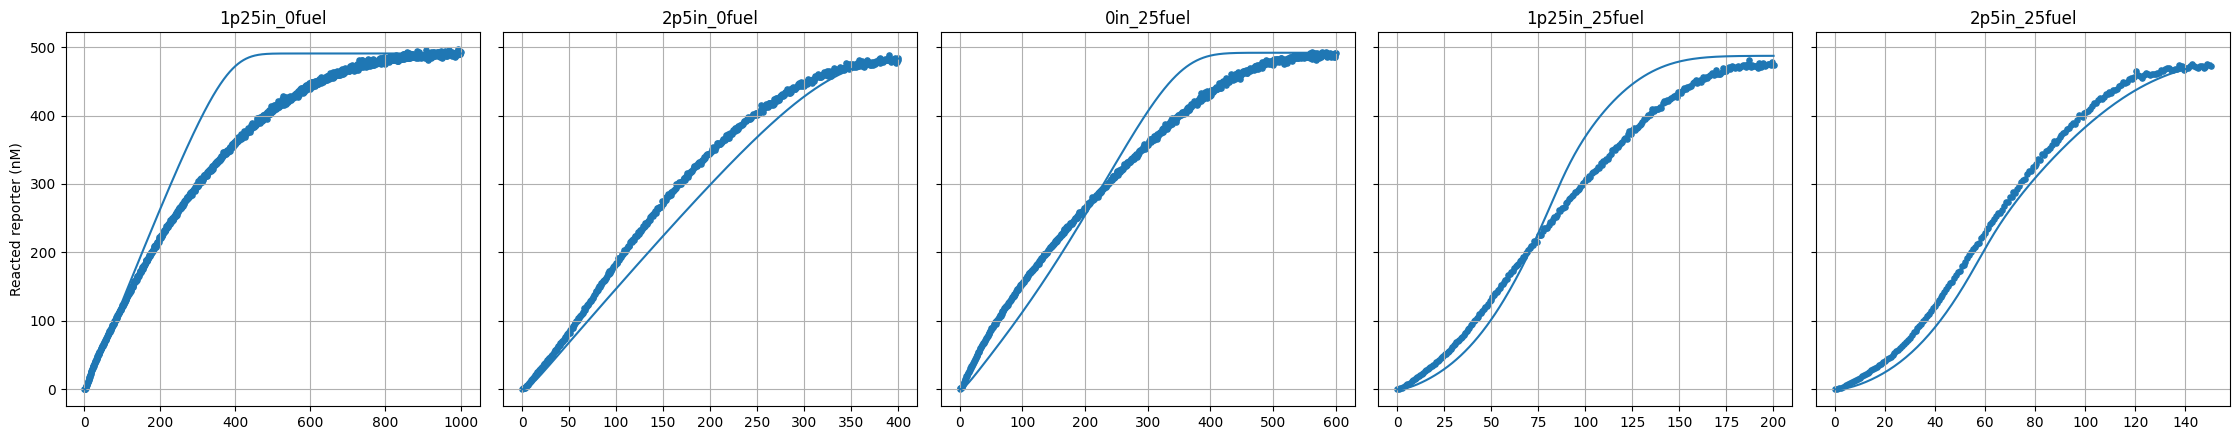

In [33]:
# ============================================================
# Plot fitted datasets (model vs experiment)
# ============================================================

# Create subplots: one panel per dataset
# sharey=True ensures all plots use the same y-axis for comparison
fig, axes = plt.subplots(
    1,
    len(datasets),
    figsize=(4.5 * len(datasets), 4.5),
    sharey=True
)

# If only one dataset, make axes iterable for consistency
if len(datasets) == 1:
    axes = [axes]


# ------------------------------------------------------------
# Plot each dataset
# ------------------------------------------------------------
for ax, d in zip(axes, datasets):

    # Generate model prediction for this dataset
    x_model = predict(d, best_fit_params)

    # Plot model prediction (line)
    ax.plot(d["t_exp"], x_model)

    # Plot experimental data (points)
    ax.scatter(d["t_exp"], d["x_exp"], s=14)

    # Title = condition name
    ax.set_title(d["name"])

    # Enable grid for readability
    ax.grid(True)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

# Label y-axis only once (shared across all panels)
axes[0].set_ylabel("Reacted reporter (nM)")

# Adjust layout to prevent overlap
plt.tight_layout()

# ------------------------------------------------------------
# Save + show
# ------------------------------------------------------------

fig.savefig(
    FIGURES_DIR / f"{RUN_NAME}_fit_timecourses.png",
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_fit_timecourses.png'}")
plt.show()

In [34]:
# ============================================================
# Plot held-out dataset (prediction vs experiment)
# ============================================================

# Only generate held-out prediction plot if a held-out dataset exists
if HELD_OUT_DATASET is not None:

    # Select the dataset that was NOT used during fitting
    d = HELD_OUT_DATASET

    # Generate model prediction using fitted parameters
    x_pred = predict(d, best_fit_params)

    # Create a new figure
    plt.figure(figsize=(5, 4))


    # ------------------------------------------------------------
    # Plot model prediction
    # ------------------------------------------------------------

    # Dashed red line = model prediction (not fitted to this data)
    plt.plot(
        d["t_exp"],
        x_pred,
        "--",
        color="red",
        label="Prediction"
    )


    # ------------------------------------------------------------
    # Plot experimental data
    # ------------------------------------------------------------

    # Scatter points = actual experimental measurements
    plt.scatter(
        d["t_exp"],
        d["x_exp"],
        s=14,
        label="Experiment"
    )


    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------

    # Title indicates this dataset was held-out during fitting
    plt.title(f"{d['name']} (held-out)")

    # Add legend to distinguish prediction vs data
    plt.legend()

    # Grid for readability
    plt.grid(True)

    # ------------------------------------------------------------
    # Save + show
    # ------------------------------------------------------------

    # Save figure before showing
    plt.savefig(
        FIGURES_DIR / f"{RUN_NAME}_heldout_prediction.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_heldout_prediction.png'}")
    plt.show()

else:
    print("\nNo held-out dataset to plot.")


No held-out dataset to plot.


Saved figure → figures/fit_exps12345_model3_cost_landscapes.png


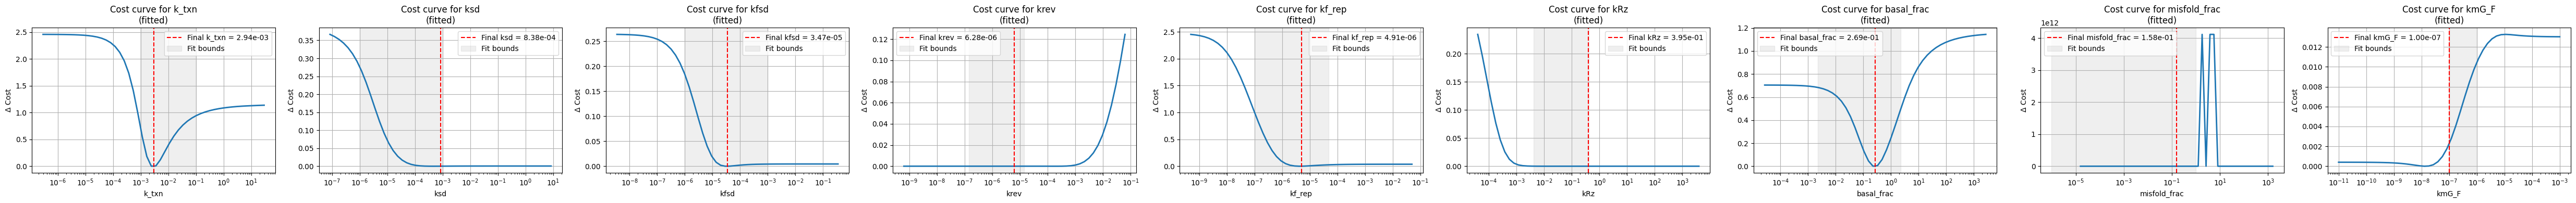

In [35]:
# ============================================================
# Cost landscapes for fitted parameters
#
# Purpose: 
# We will plot the cost landscape for each fitted parameter 
# by varying it across a wide range 
# while keeping other parameters fixed at their best-fit values.
# ============================================================

# Base parameters to scan (those that were fitted)
SCAN_PARAMS = FIT_PARAMS.copy()
# Width of scan range in log10 space (e.g. 4 means ±4 orders of magnitude around best fit)
SCAN_HALF_WIDTH_LOG10 = 4.0
# Number of points to evaluate across the scan range for each parameter
N_SCAN = 50

# Number of parameters being scanned (determines number of subplots)
n_params = len(SCAN_PARAMS)
fig, axes = plt.subplots(1, n_params, figsize=(5.5 * n_params, 4))

# If only one parameter is scanned
if n_params == 1:
    # Make axes iterable for consistency (even if there's only one subplot)
    axes = [axes]

# ------------------------------------------------------------
# Loop through each scanned parameter
# ------------------------------------------------------------
for ax, p in zip(axes, SCAN_PARAMS):

    center_val = best_fit_params[p]
    center_log10 = np.log10(center_val)

    param_vals = np.logspace(
        center_log10 - SCAN_HALF_WIDTH_LOG10,
        center_log10 + SCAN_HALF_WIDTH_LOG10,
        N_SCAN
    )

    cost_vals = []


    # --------------------------------------------------------
    # Evaluate cost across parameter values
    # --------------------------------------------------------
    for p_test in param_vals:

        # Copy best-fit parameters
        params = best_fit_params.copy()

        # Replace only the scanned parameter
        params[p] = p_test

        # Use normalized residual helper (IMPORTANT)
        res_all = np.concatenate([
            compute_normalized_residual(d, params)
            for d in datasets
        ])

        # Cost = sum of squared normalized residuals
        cost_vals.append(np.sum(res_all**2))


    cost_vals = np.array(cost_vals)

    delta_cost = cost_vals - np.min(cost_vals)

    ax.semilogx(param_vals, delta_cost, linewidth=2)

    ax.axvline(
        best_fit_params[p],
        linestyle="--",
        linewidth=1.5,
        color="red",
        label=f"Final {p} = {best_fit_params[p]:.2e}"
    )

    if p in CUSTOM_PARAM_BOUNDS:
        lower_bound, upper_bound = CUSTOM_PARAM_BOUNDS[p]
        ax.axvspan(
            lower_bound,
            upper_bound,
            alpha=0.12,
            color="gray",
            label="Fit bounds"
        )

    title_suffix = "(fitted)" if p in FIT_PARAMS else "(fixed)"

    ax.set_xlabel(p)
    ax.set_ylabel("Δ Cost")
    ax.set_title(f"Cost curve for {p}\n{title_suffix}")

    ax.grid(True)
    ax.legend()

plt.tight_layout()

# ------------------------------------------------------------
# Save + show
# ------------------------------------------------------------

fig.savefig(
    FIGURES_DIR / f"{RUN_NAME}_cost_landscapes.png",
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_cost_landscapes.png'}")
plt.show()

In [36]:
# ------------------------------------------------------------
# Save run summary to text file
# ------------------------------------------------------------

summary_file = RESULTS_DIR / f"{RUN_NAME}_summary.txt"

with open(summary_file, "w") as f:

    # ============================================================
    # Run metadata
    # ============================================================

    f.write("RUN SUMMARY\n")
    f.write("="*50 + "\n\n")

    f.write(f"Run name       : {RUN_NAME}\n")
    f.write(f"Model          : {MODEL_NAME}\n")
    f.write(f"Mode           : {MODE}\n")
    f.write(f"Fit conditions : {FIT_CONDITIONS}\n")
    f.write(f"Held-out       : {HELD_OUT_CONDITION}\n")
    f.write(f"N starts       : {N_STARTS}\n")
    f.write(f"Random seed    : {RANDOM_SEED}\n")
    f.write(f"Excel file     : {EXCEL_FILE}\n")
    f.write(f"Sheet          : {EXCEL_SHEET}\n")
    f.write(f"Results file   : {FIT_RESULTS_FILE}\n\n")


    # ============================================================
    # Fit parameters
    # ============================================================

    f.write("FIT PARAMETERS\n")
    f.write("-"*50 + "\n")

    for p, v in best_fit_params.items():
        f.write(f"{p:<15} = {v:.8e}\n")

    f.write("\n")


    # ============================================================
    # Fit statistics
    # ============================================================

    best_sse = 2 * best_cost

    f.write("FIT STATISTICS\n")
    f.write("-"*50 + "\n")
    f.write(f"Best cost (0.5 * SSE) = {best_cost:.8e}\n")
    f.write(f"Best SSE (normalized) = {best_sse:.8e}\n")
    f.write("\n")


    # ============================================================
    # RMSE (per dataset)
    # ============================================================

    f.write("RMSE (per dataset)\n")
    f.write("-"*50 + "\n")

    for d in datasets:
        rmse = compute_rmse(d, best_fit_params)
        f.write(f"{d['name']:<25} = {rmse:.8e}\n")

    if HELD_OUT_DATASET is not None:

        rmse_ho = compute_rmse(
            HELD_OUT_DATASET,
            best_fit_params
        )

        f.write(
            f"\nHeld-out ({HELD_OUT_DATASET['name']}) = "
            f"{rmse_ho:.8e}\n\n"
        )

    else:

        f.write("\nHeld-out = None\n\n")


    # ============================================================
    # Global RMSE
    # ============================================================

    f.write("GLOBAL RMSE\n")
    f.write("-"*50 + "\n")

    global_fit = compute_global_rmse(
        datasets,
        best_fit_params
    )

    if HELD_OUT_DATASET is not None:

        datasets_all = datasets + [HELD_OUT_DATASET]

    else:

        datasets_all = datasets

    global_all = compute_global_rmse(
        datasets_all,
        best_fit_params
    )

    f.write(f"Fit datasets : {global_fit:.8e}\n")
    f.write(f"All datasets : {global_all:.8e}\n\n")


    # ============================================================
    # Dataset windows (fit ranges + metadata)
    # ============================================================

    f.write("DATASET WINDOWS\n")
    f.write("-"*50 + "\n")

    for d in datasets:

        f.write(f"{d['name']}\n")
        f.write(f"  Type        : fitted\n")
        f.write(f"  IN          : {d['IN_conc']} nM\n")
        f.write(f"  Fuel        : {d['Fuel_conc']} nM\n")
        f.write(f"  t_start     : {d['t_exp'][0]:.2f} min\n")
        f.write(f"  t_end       : {d['t_exp'][-1]:.2f} min\n")
        f.write(f"  n_points    : {len(d['t_exp'])}\n")
        f.write(f"  DRL_0       : {d['DRL_0']:.2f} nM\n\n")


    # ============================================================
    # Held-out dataset metadata
    # ============================================================

    if HELD_OUT_DATASET is not None:

        d = HELD_OUT_DATASET

        f.write(f"{d['name']}\n")
        f.write(f"  Type        : held-out\n")
        f.write(f"  IN          : {d['IN_conc']} nM\n")
        f.write(f"  Fuel        : {d['Fuel_conc']} nM\n")
        f.write(f"  t_start     : {d['t_exp'][0]:.2f} min\n")
        f.write(f"  t_end       : {d['t_exp'][-1]:.2f} min\n")
        f.write(f"  n_points    : {len(d['t_exp'])}\n")
        f.write(f"  DRL_0       : {d['DRL_0']:.2f} nM\n\n")

    else:

        f.write("No held-out dataset because all conditions were fitted.\n\n")


print(f"Saved summary → {summary_file}")

Saved summary → results/fit_exps12345_model3_summary.txt
